
## Tarea 6: Clasificación según conjunto de datos

Conjunto de datos a analizar: Cardiotocography

In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cardiotocography = fetch_ucirepo(id=193) 
  
# data (as pandas dataframes) 
X = cardiotocography.data.features 
y = cardiotocography.data.targets 
  
# metadata 
print(cardiotocography.metadata) 
  
# variable information 
print(cardiotocography.variables) 


{'uci_id': 193, 'name': 'Cardiotocography', 'repository_url': 'https://archive.ics.uci.edu/dataset/193/cardiotocography', 'data_url': 'https://archive.ics.uci.edu/static/public/193/data.csv', 'abstract': 'The dataset consists of measurements of fetal heart rate (FHR) and uterine contraction (UC) features on cardiotocograms classified by expert obstetricians.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 2126, 'num_features': 21, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['CLASS', 'NSP'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C51S4N', 'creators': ['D. Campos', 'J. Bernardes'], 'intro_paper': None, 'additional_info': {'summary': '2126 fetal cardiotocograms (CTGs) were automatically processed and the respective diagnostic features measured. The CTGs were also classified

### 1. Análisis exploratorio de datos
En esta sección revisamos la calidad del conjunto de datos, la distribución de las variables y el balance de las clases.

Dimensiones del dataset: (2126, 22)

Tipos de datos:
LB            int64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV          int64
MSTV        float64
ALTV          int64
MLTV        float64
Width         int64
Min           int64
Max           int64
Nmax          int64
Nzeros        int64
Mode          int64
Mean          int64
Median        int64
Variance      int64
Tendency      int64
target          str
dtype: object

Valores faltantes por columna:
LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Min         0
Max         0
Nmax        0
Nzeros      0
Mode        0
Mean        0
Median      0
Variance    0
Tendency    0
target      0
dtype: int64

Conteo de clases:
target
normal          1655
suspect          295
pathological     176
Name: count, dtype: int64

Descripción estadística 

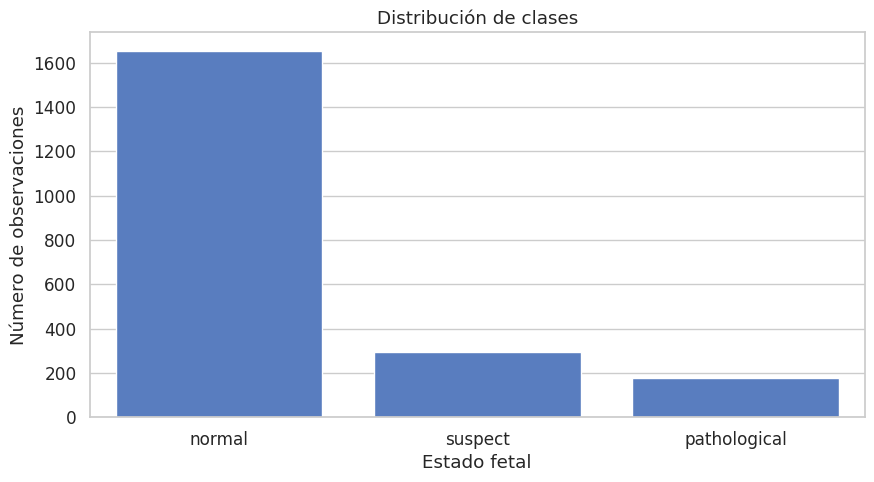

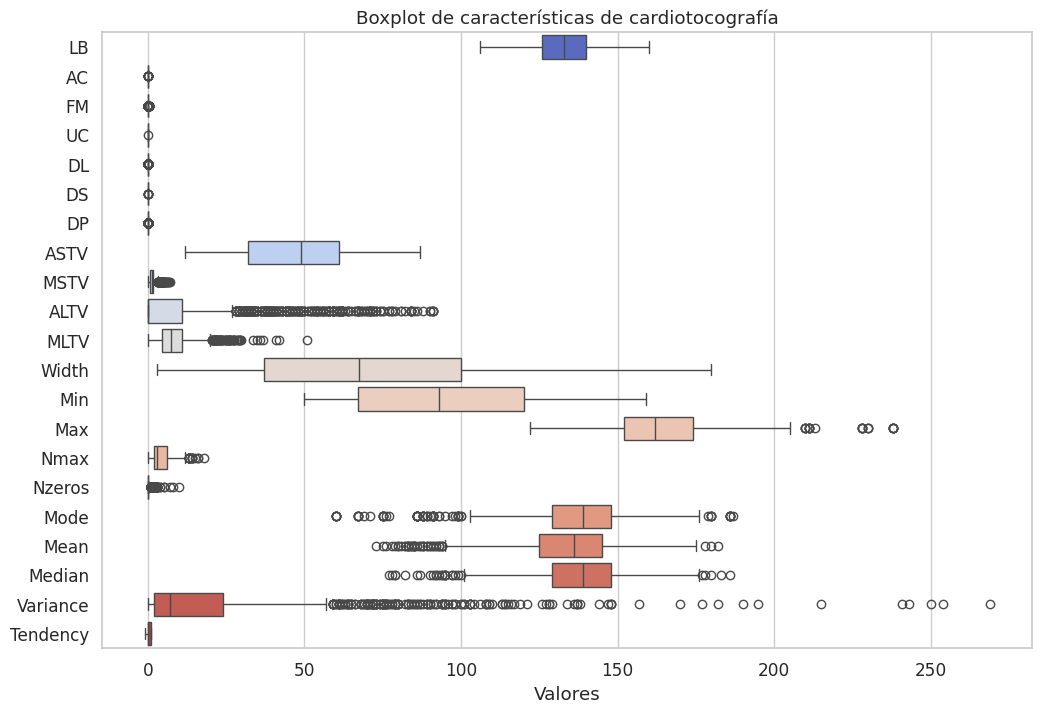

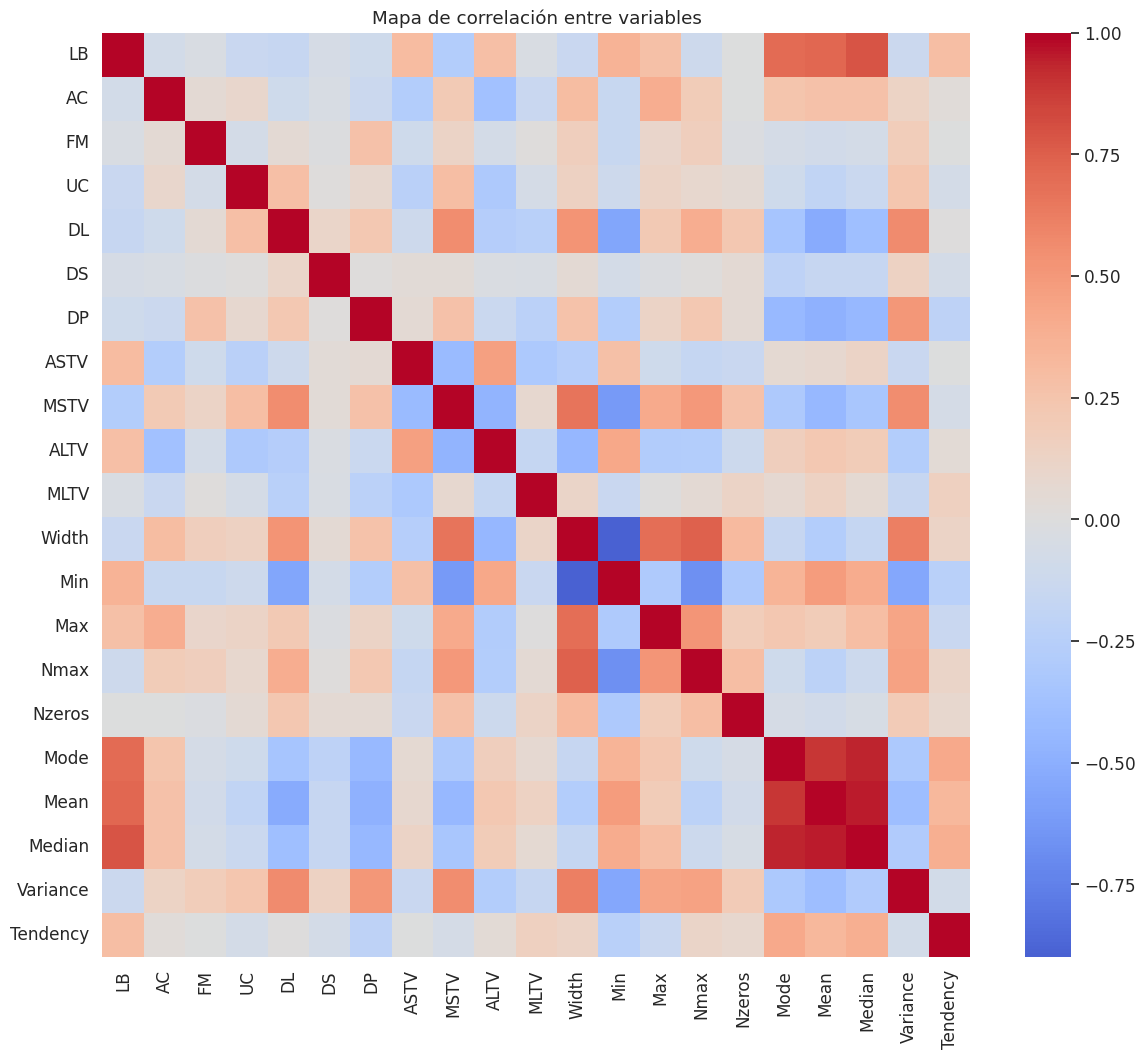

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Construir un dataframe completo para facilitar el EDA
data = X.copy()
if isinstance(data, pd.DataFrame):
    data = data.copy()
else:
    data = pd.DataFrame(data, columns=X.columns)

# Asegurar que y tenga índices compatibles
if isinstance(y, pd.Series):
    y_series = y.copy()
else:
    y_series = pd.Series(y["NSP"].values, name="target")

# Mapas de etiquetas si el dataset usa clases numéricas conocidas
label_map = {1: "normal", 2: "suspect", 3: "pathological"}
if set(y_series.unique()).issubset(label_map.keys()):
    y_names = y_series.map(label_map)
else:
    y_names = y_series.astype(str)

data["target"] = y_names

# 1. Revisar tamaño, tipos y valores faltantes
print("Dimensiones del dataset:", data.shape)
print("\nTipos de datos:")
print(data.dtypes)
print("\nValores faltantes por columna:")
print(data.isna().sum())

# 2. Balance de clases y resumen estadístico
print("\nConteo de clases:")
print(data["target"].value_counts())
print("\nDescripción estadística de las características:")
print(data.describe().T)

# 3. Visualizaciones principales
plt.figure(figsize=(10, 5))
ax = sns.countplot(x="target", data=data, order=data["target"].value_counts().index)
ax.set_title("Distribución de clases")
plt.xlabel("Estado fetal")
plt.ylabel("Número de observaciones")
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(data=data.drop(columns="target"), orient="h", palette="coolwarm")
plt.title("Boxplot de características de cardiotocografía")
plt.xlabel("Valores")
plt.show()

# Mapa de correlación para observar relaciones lineales
corr = data.drop(columns="target").corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Mapa de correlación entre variables")
plt.show()

### 2. Definición del problema de clasificación
El objetivo es predecir el estado fetal a partir de las señales de cardiotocografía. Esto corresponde a un problema de clasificación supervisada multiclase.

- Dataset: `Cardiotocography` del repositorio UCI.
- Variables predictoras: características extraídas del registro cardiotocográfico.
- Variable objetivo: `target` con las clases de estado fetal.
- Tipo de problema: clasificación multiclase.

### 3. Diseño del experimento
1. Dataset: usar `X` como características y `y` como etiqueta.
2. Tipo de entrenamiento: dividir en entrenamiento y prueba con muestreo estratificado.
3. Modelos a comparar:
   - Regresión logística
   - Random Forest
   - Gradient Boosting
4. Métricas de comparación:
   - Accuracy
   - Balanced accuracy
   - F1-score macro
   - Matriz de confusión y reporte de clasificación

In [11]:
# Preparación del conjunto de entrenamiento y prueba
X_full = data.drop(columns="target")
y_full = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.25,
    random_state=42,
    stratify=y_full,
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=150, random_state=42)),
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=150, random_state=42)),
    ]),
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    results.append({
        "model": name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1,
        "classifier": model,
        "y_pred": y_pred,
    })

results_df = pd.DataFrame(results)[["model", "accuracy", "balanced_accuracy", "f1_macro"]]
results_df.sort_values(by="f1_macro", ascending=False, inplace=True)
print(results_df)

Tamaño entrenamiento: (1594, 21)
Tamaño prueba: (532, 21)
                 model  accuracy  balanced_accuracy  f1_macro
2    Gradient Boosting  0.951128           0.916805  0.917696
1        Random Forest  0.941729           0.888140  0.897936
0  Logistic Regression  0.896617           0.811511  0.810733


### 4. Resultados del experimento
Presentamos las métricas comparativas y el análisis de los modelos entrenados.


Modelo: Logistic Regression
              precision    recall  f1-score   support

      normal     0.9470    0.9493    0.9481       414
pathological     0.8444    0.8636    0.8539        44
     suspect     0.6389    0.6216    0.6301        74

    accuracy                         0.8966       532
   macro avg     0.8101    0.8115    0.8107       532
weighted avg     0.8957    0.8966    0.8961       532



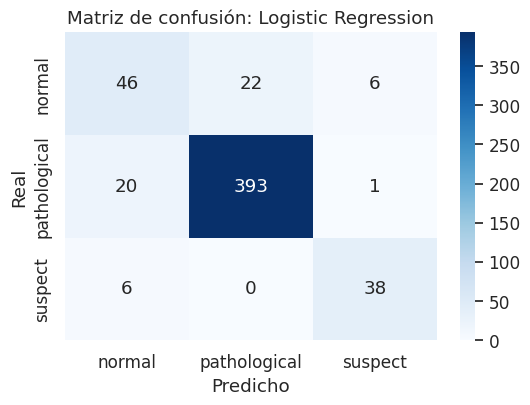


Modelo: Random Forest
              precision    recall  f1-score   support

      normal     0.9596    0.9758    0.9677       414
pathological     0.9318    0.9318    0.9318        44
     suspect     0.8358    0.7568    0.7943        74

    accuracy                         0.9417       532
   macro avg     0.9091    0.8881    0.8979       532
weighted avg     0.9401    0.9417    0.9406       532



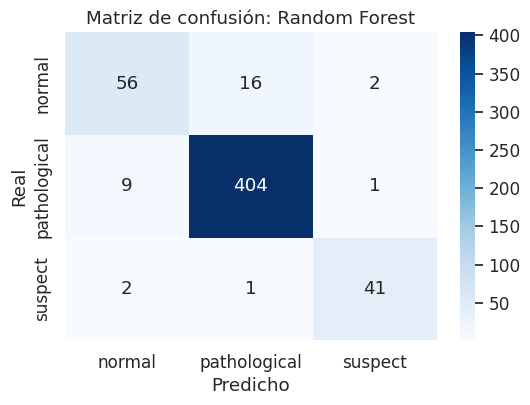


Modelo: Gradient Boosting
              precision    recall  f1-score   support

      normal     0.9665    0.9758    0.9712       414
pathological     0.9149    0.9773    0.9451        44
     suspect     0.8806    0.7973    0.8369        74

    accuracy                         0.9511       532
   macro avg     0.9207    0.9168    0.9177       532
weighted avg     0.9503    0.9511    0.9503       532



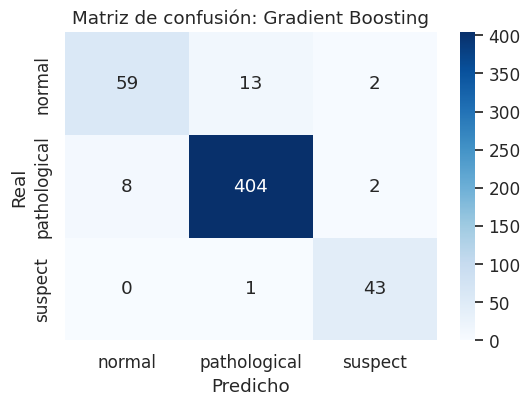


Top 10 características más importantes del Random Forest:
MSTV      0.132901
ASTV      0.130316
Mean      0.102745
ALTV      0.101699
Mode      0.061782
Median    0.058034
AC        0.050765
MLTV      0.047632
DP        0.045536
LB        0.041188
dtype: float64


/tmp/ipykernel_5958/1060708752.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.head(10), y=feature_importance.head(10).index, palette="viridis")


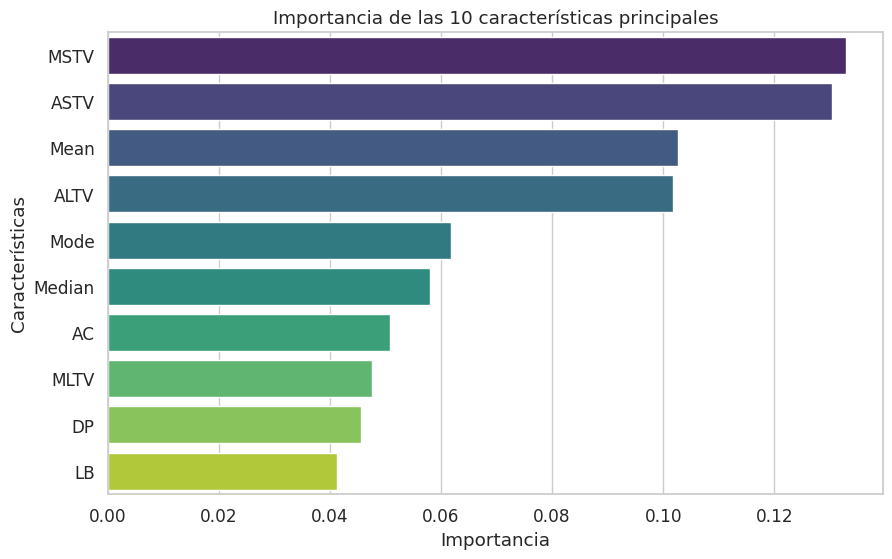

In [12]:
# Reportes ordenados para cada modelo
for row in results:
    print("\nModelo:", row["model"])
    print(classification_report(y_test, row["y_pred"], digits=4))
    cm = confusion_matrix(y_test, row["y_pred"], labels=y_full.unique())
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=np.unique(y_full), yticklabels=np.unique(y_full))
    ax.set_title(f"Matriz de confusión: {row['model']}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    plt.show()

# Importancia de variables para Random Forest
rf_model = next(item for item in results if item["model"] == "Random Forest")["classifier"].named_steps["clf"]
feature_importance = pd.Series(rf_model.feature_importances_, index=X_full.columns).sort_values(ascending=False)
print("\nTop 10 características más importantes del Random Forest:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.head(10), y=feature_importance.head(10).index, palette="viridis")
plt.title("Importancia de las 10 características principales")
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.show()

### 5. Análisis de resultados
- Se observó la distribución de clases y la presencia de leve desequilibrio.
- El modelo con mejor desempeño según F1 macro es el que capture mejor las tres clases de forma balanceada.
- El análisis de la matriz de confusión permite ver qué clases se confunden con mayor frecuencia.
- Las variables más importantes del Random Forest indican qué mediciones tienen mayor poder predictivo.

Conclusión: elegir el modelo con la mejor combinación de `balanced_accuracy` y `f1_macro`, evaluando además si el modelo generaliza bien a la muestra de prueba.